# Termination Probability

> Measure and visualize how often recall stops at each output position.

The termination probability curve summarizes when participants stop recalling. Two modes are available: *simple* mode reports the raw proportion of trials that terminate at each output position, while *conditional* mode divides by how many trials reached that position, giving a stopping hazard rate.

This notebook is parameterized for use with [papermill](https://papermill.readthedocs.io/).

| Parameter | Description |
|-----------|-------------|
| `data_path` | Path to HDF5 dataset file |
| `figure_dir` | Directory for saving figures |
| `figure_str` | Filename for saved figure (empty string to skip saving) |
| `ylim` | Y-axis limits as tuple, or `None` for auto |
| `mixed_trial_query` | Query string selecting mixed (repeated-item) trials |
| `control_trial_query` | Query string selecting pure (control) trials |
| `control_shuffles` | Number of shuffled control blocks per subject |
| `mode` | `"conditional"` or `"simple"` |

: Notebook parameters {#tbl-parameters}

In [1]:
#| include: false
from nbdev.showdoc import show_doc

In [2]:
#| code-summary: Imports and setup
import os
import warnings

import jax.numpy as jnp
import matplotlib.pyplot as plt

from jaxcmr.analyses.termination_probability import (
    conditional_termination_probability,
    plot_termination_probability,
    simple_termination_probability,
    subject_output_length_mean,
    subject_output_length_median,
    test_output_length_mean_vs_control,
    test_output_length_median_vs_control,
)
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data
from jaxcmr.repetition import make_control_dataset

warnings.filterwarnings("ignore")


def save_figure(figure_dir, figure_str, suffix=None):
    plt.tight_layout()
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    figure_path = os.path.join(figure_dir, f"{figure_str}{suffix_str}.png")
    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()

In [3]:
#| code-summary: Parameters for this analysis

data_path = "data/LohnasKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
mixed_trial_query = "data['list_type'] == 4"
control_trial_query = "data['list_type'] == 1"
control_shuffles = 10
mode = "conditional"

In [4]:
#| code-summary: Load data and build control dataset
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, mixed_trial_query)

control_dataset = make_control_dataset(
    data, mixed_trial_query, control_trial_query, control_shuffles
)
control_mask = generate_trial_mask(control_dataset, mixed_trial_query)

datasets = [data, control_dataset]
masks = [trial_mask, control_mask]

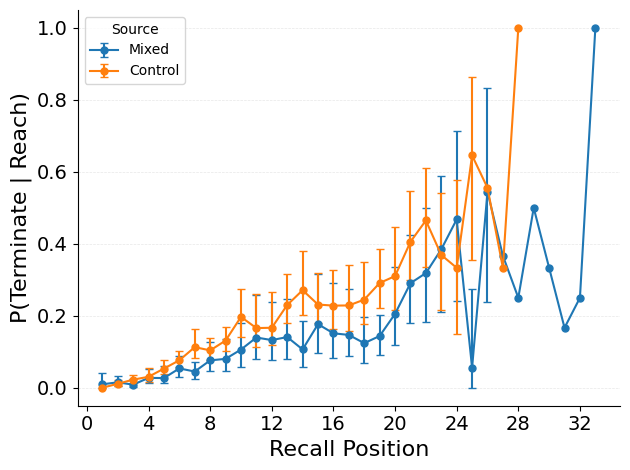

In [5]:
#| code-summary: Plot termination probability
#| label: fig-termination
#| fig-cap: "Termination probability by recall output position."
plot_termination_probability(
    datasets=datasets,
    trial_masks=masks,
    mode=mode,
    labels=["Mixed", "Control"],
    contrast_name="Source",
)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str)

## Statistical Tests

In [6]:
#| code-summary: Test output length (mean and median)
observed_means = subject_output_length_mean(data, trial_mask)
control_means = subject_output_length_mean(control_dataset, control_mask)

mean_result = test_output_length_mean_vs_control(observed_means, control_means)

print()
print("=" * 70)
print("Output Length Test (Mean)")
print("=" * 70)
print("H0: Mean output length is the same in observed and control data.")
print(mean_result)

observed_medians = subject_output_length_median(data, trial_mask)
control_medians = subject_output_length_median(control_dataset, control_mask)

median_result = test_output_length_median_vs_control(observed_medians, control_medians)

print()
print("=" * 70)
print("Output Length Test (Median)")
print("=" * 70)
print("H0: Median output length is the same in observed and control data.")
print(median_result)


Output Length Test (Mean)
H0: Mean output length is the same in observed and control data.
N=35
Mean (observed): 13.6381
Mean (control): 13.3552
Mean difference: 0.2829
t-stat: 0.973 p=0.3375
W-stat: 253.5 p=0.3138



Output Length Test (Median)
H0: Median output length is the same in observed and control data.
N=35
Mean (observed): 13.8143
Mean (control): 13.1857
Mean difference: 0.6286
t-stat: 1.752 p=0.0888
W-stat: 120.5 p=0.0595


---

## Reference

In [7]:
#| echo: false
show_doc(plot_termination_probability)

---

### plot_termination_probability

>      plot_termination_probability (datasets:Union[Sequence[jaxcmr.typing.Recal
>                                    lDataset],jaxcmr.typing.RecallDataset], tri
>                                    al_masks:Union[Sequence[jaxtyping.Bool[Arra
>                                    y,'trial_count']],jaxtyping.Bool[Array,'tri
>                                    al_count']], mode:str='conditional',
>                                    color_cycle:Optional[list[str]]=None,
>                                    labels:Optional[Sequence[str]]=None,
>                                    contrast_name:Optional[str]=None, axis:Opti
>                                    onal[matplotlib.axes._axes.Axes]=None,
>                                    confidence_level:float=0.95)

*Plot termination probability curves.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| datasets | Union |  | One or more datasets to plot. |
| trial_masks | Union |  | Boolean mask(s) selecting trials. |
| mode | str | conditional | ``"conditional"`` or ``"simple"``. |
| color_cycle | Optional | None | Colors for each curve. |
| labels | Optional | None | Legend labels for each curve. |
| contrast_name | Optional | None | Legend title. |
| axis | Optional | None | Existing Axes to plot on. |
| confidence_level | float | 0.95 | Confidence level for error bounds. |
| **Returns** | **Axes** |  | **Matplotlib Axes with termination curves.** |

In [8]:
#| echo: false
show_doc(conditional_termination_probability)

---

### conditional_termination_probability

>      conditional_termination_probability (dataset:jaxcmr.typing.RecallDataset)

*Conditional termination probability by recall position.*

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| dataset | RecallDataset | Recall dataset containing ``recalls``. |
| **Returns** | **Float[Array, 'recall_positions']** | **P(stop \| reached) at each output position.** |

In [9]:
# One trial fills all slots, the other stops after one recall
dataset = {
    "subject": jnp.ones((2, 1), dtype=jnp.int32),
    "listLength": jnp.full((2, 1), 4, dtype=jnp.int32),
    "recalls": jnp.array([[1, 2, 3, 4], [7, 0, 0, 0]], dtype=jnp.int32),
}

hazard = conditional_termination_probability(dataset)
# P(stop|reached): position 2 = 0.5, position 4 = 1.0
assert jnp.allclose(hazard, jnp.array([0.0, 0.5, 0.0, 1.0]))

In [10]:
#| echo: false
show_doc(simple_termination_probability)

---

### simple_termination_probability

>      simple_termination_probability (dataset:jaxcmr.typing.RecallDataset)

*Termination probability by recall position.*

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| dataset | RecallDataset | Recall dataset containing ``recalls``. |
| **Returns** | **Float[Array, 'recall_positions']** | **Probability of stopping at each output position.** |

In [11]:
# Both trials stop after the first recall
dataset = {
    "subject": jnp.ones((2, 1), dtype=jnp.int32),
    "listLength": jnp.full((2, 1), 4, dtype=jnp.int32),
    "recalls": jnp.array([[5, 0, 0, 0], [8, 0, 0, 0]], dtype=jnp.int32),
}

curve = simple_termination_probability(dataset)
assert jnp.allclose(curve, jnp.array([0.0, 1.0, 0.0, 0.0]))

In [12]:
#| echo: false
show_doc(subject_output_length_mean)

---

### subject_output_length_mean

>      subject_output_length_mean (dataset:jaxcmr.typing.RecallDataset,
>                                  trial_mask:jaxtyping.Bool[Array,'trial_count'
>                                  ])

*Mean output lengths per subject.*

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| dataset | RecallDataset | Recall dataset containing trial data. |
| trial_mask | Bool[Array, 'trial_count'] | Boolean mask selecting trials. |
| **Returns** | **ndarray** | **Per-subject mean output lengths.** |

In [13]:
#| echo: false
show_doc(subject_output_length_median)

---

### subject_output_length_median

>      subject_output_length_median (dataset:jaxcmr.typing.RecallDataset,
>                                    trial_mask:jaxtyping.Bool[Array,'trial_coun
>                                    t'])

*Median output lengths per subject.*

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| dataset | RecallDataset | Recall dataset containing trial data. |
| trial_mask | Bool[Array, 'trial_count'] | Boolean mask selecting trials. |
| **Returns** | **ndarray** | **Per-subject median output lengths.** |

In [14]:
#| echo: false
show_doc(test_output_length_mean_vs_control)

---

### test_output_length_mean_vs_control

>      test_output_length_mean_vs_control (observed_means:numpy.ndarray,
>                                          control_means:numpy.ndarray)

*Test mean output length: observed vs control.*

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| observed_means | ndarray | Per-subject mean output lengths (observed). |
| control_means | ndarray | Per-subject mean output lengths (control). |
| **Returns** | **OutputLengthTestResult** | **Paired test statistics.** |

In [15]:
#| echo: false
show_doc(test_output_length_median_vs_control)

---

### test_output_length_median_vs_control

>      test_output_length_median_vs_control (observed_medians:numpy.ndarray,
>                                            control_medians:numpy.ndarray)

*Test median output length: observed vs control.*

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| observed_medians | ndarray | Per-subject median output lengths (observed). |
| control_medians | ndarray | Per-subject median output lengths (control). |
| **Returns** | **OutputLengthTestResult** | **Paired test statistics.** |